# A3 05 — Historical ground-census validation

## Purpose
This notebook asks whether the Eastern/Sweetwaters bone assemblage gives a similar answer when the living community is represented by ground counts rather than aerial counts. All ground and Earthwatch entries from 1996–2003 are treated as valid, and confirmed blank cells are zeros. Ground and aerial counts remain separate methods.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'scripts'))
from a3_common import *
processed_dir, output_dir = ensure_a3_directories(ROOT)
ground = pd.read_pickle(processed_dir / 'ground_historical_sweetwaters.pkl')
historical_aerial = pd.read_pickle(processed_dir / 'aerial_historical_sweetwaters.pkl')
bones = pd.read_pickle(processed_dir / 'bones_primary_excluding_2024.pkl')
bones_east = bones[bones['Sector'].eq('Eastern')].copy()
ground_taxa = eligible_shared_taxa(ground, bones_east)
print(f'Matched ground–bone taxa: {len(ground_taxa)}')
print(ground_taxa)
pd.DataFrame({'dataset':['ground','historical aerial'],'years':[ground['Year'].nunique(),historical_aerial['Year'].nunique()],'first_year':[ground['Year'].min(),historical_aerial['Year'].min()],'last_year':[ground['Year'].max(),historical_aerial['Year'].max()]})


Matched ground–bone taxa: 14
['Aepyceros melampus', 'Alcelaphus buselaphus', 'Diceros bicornis', 'Equus burchellii', 'Eudorcas thomsonii', 'Giraffa camelopardalis', 'Kobus ellipsiprymnus', 'Loxodonta africana', 'Nanger granti', 'Oryx beisa', 'Phacochoerus africanus', 'Redunca redunca', 'Syncerus caffer', 'Taurotragus oryx']


,dataset,years,first_year,last_year
0,ground,7,1996,2003
1,historical aerial,3,2000,2003


## Analysis 1 — Ground census versus Eastern bone MNI

Ground counts are pooled across 1996–2003 and compared with Eastern bone MNI assigned to the same estimated-death-year interval. Relative abundance, Bray–Curtis, Pearson, and Spearman are reported. A sensitivity comparison uses all Eastern primary bone years, acknowledging broader time averaging.

**Plain-language example.** We first compare two summaries covering approximately the same historical window. We then ask whether the answer changes when the full Eastern bone record is used.


In [2]:
window_start, window_end = int(ground['Year'].min()), int(ground['Year'].max())
bones_window = bones_east[bones_east['Year'].between(window_start, window_end)].copy()
ground_all = ground[ground['Species'].isin(ground_taxa)].groupby('Species')['Total'].sum()
bone_window = bones_window[bones_window['Species'].isin(ground_taxa)].groupby('Species')['Total'].sum()
bone_all_east = bones_east[bones_east['Species'].isin(ground_taxa)].groupby('Species')['Total'].sum()
comparison_rows = [
 {'comparison':'Ground 1996–2003 vs Eastern bone estimated years 1996–2003','ground_count':ground_all.sum(),'bone_MNI':bone_window.sum(),**composition_comparison(ground_all,bone_window)},
 {'comparison':'Ground 1996–2003 vs all Eastern primary bone years','ground_count':ground_all.sum(),'bone_MNI':bone_all_east.sum(),**composition_comparison(ground_all,bone_all_east)}]
ground_bone_results = pd.DataFrame(comparison_rows)
ground_bone_results.to_csv(output_dir / 'A3_05_ground_bone_fidelity.csv', index=False)
ground_bone_drivers = taxon_contributions(ground_all, bone_window)
ground_bone_drivers.to_csv(output_dir / 'A3_05_ground_bone_taxon_contributions.csv')
ground_bone_results.round(3)


,comparison,ground_count,bone_MNI,bray_curtis,pearson,spearman,taxa_compared
0,Ground 1996–2003 vs Eastern bone estimated yea...,22028.0,58,0.242,0.919,0.732,14
1,Ground 1996–2003 vs all Eastern primary bone y...,22028.0,293,0.167,0.953,0.857,14


## Analysis 2 — Ground versus aerial census

The methods overlap in 2002 and 2003. Each year is compared separately, followed by a pooled two-year comparison. With only two paired years, this is a descriptive calibration rather than a formal method-equivalence test.


In [3]:
overlap_years = sorted(set(ground['Year']) & set(historical_aerial['Year']))
method_taxa = sorted(set(ground_taxa) & set(historical_aerial['Species']))
method_rows = []
for year in overlap_years:
 g = ground[(ground['Year'].eq(year)) & ground['Species'].isin(method_taxa)].set_index('Species')['Total']
 a = historical_aerial[(historical_aerial['Year'].eq(year)) & historical_aerial['Species'].isin(method_taxa)].set_index('Species')['Total']
 method_rows.append({'comparison':str(year),'ground_count':g.sum(),'aerial_count':a.sum(),**composition_comparison(g,a)})
g_pool = ground[ground['Year'].isin(overlap_years) & ground['Species'].isin(method_taxa)].groupby('Species')['Total'].sum()
a_pool = historical_aerial[historical_aerial['Year'].isin(overlap_years) & historical_aerial['Species'].isin(method_taxa)].groupby('Species')['Total'].sum()
method_rows.append({'comparison':'2002–2003 pooled','ground_count':g_pool.sum(),'aerial_count':a_pool.sum(),**composition_comparison(g_pool,a_pool)})
ground_aerial_results = pd.DataFrame(method_rows)
ground_aerial_results.to_csv(output_dir / 'A3_05_ground_aerial_comparison.csv', index=False)
ground_aerial_results.round(3)


,comparison,ground_count,aerial_count,bray_curtis,pearson,spearman,taxa_compared
0,2002,811.0,935.0,0.421,0.549,0.461,14
1,2003,4344.0,979.0,0.237,0.870,0.897,14
2,2002–2003 pooled,5155.0,1914.0,0.270,0.884,0.795,14


## Analysis 3 — Coverage, dominance, and source-label sensitivity

Exact-year ground–bone overlap is audited rather than assumed. Ground dominance and diversity are summarized across years. Although Earthwatch entries are valid in the primary series, a confirmed-ground-only sensitivity check shows whether the source label materially changes the pooled composition.


In [4]:
ground_matrix = annual_matrix(ground, ground_taxa)
bone_matrix = annual_matrix(bones_east, ground_taxa)
ground_diversity = annual_diversity(ground_matrix, minimum_count=1)
ground_dominance = dominance_summary(ground_matrix).assign(dataset='ground')
ground_diversity.to_csv(output_dir / 'A3_05_ground_annual_diversity.csv', index=False)
ground_dominance.to_csv(output_dir / 'A3_05_ground_taxon_dominance.csv', index=False)
coverage = pd.DataFrame({'ground_count':ground_matrix.sum(axis=1),'ground_taxa':(ground_matrix>0).sum(axis=1)}).join(pd.DataFrame({'bone_MNI':bone_matrix.sum(axis=1),'bone_taxa':(bone_matrix>0).sum(axis=1)}),how='left').reset_index()
coverage['bone_MNI_ge_10'] = coverage['bone_MNI'].ge(10).fillna(False)
coverage.to_csv(output_dir / 'A3_05_ground_bone_year_coverage.csv', index=False)
confirmed = ground[~ground['SourceMethod'].str.contains('Earthwatch',case=False,na=False)]
confirmed_vec = confirmed[confirmed['Species'].isin(ground_taxa)].groupby('Species')['Total'].sum()
source_sensitivity = pd.DataFrame([{'comparison':'all valid ground vs confirmed-label ground',**composition_comparison(ground_all,confirmed_vec)},{'comparison':'confirmed-label ground vs matched-window bone',**composition_comparison(confirmed_vec,bone_window)}])
source_sensitivity.to_csv(output_dir / 'A3_05_ground_source_sensitivity.csv', index=False)
display(coverage)
display(ground_dominance.groupby('sector').head(8).round(3))
source_sensitivity.round(3)


,sector,year,ground_count,ground_taxa,bone_MNI,bone_taxa,bone_MNI_ge_10
0,Eastern,1996,3245.0,14,NaN,NaN,False
1,Eastern,1997,3501.0,14,NaN,NaN,False
2,Eastern,1998,3610.0,14,25.0,8.0,True
3,Eastern,1999,3615.0,14,NaN,NaN,False
4,Eastern,2001,2902.0,13,NaN,NaN,False
5,Eastern,2002,811.0,13,23.0,5.0,True
6,Eastern,2003,4344.0,12,10.0,5.0,True


,sector,taxon,mean_relative_abundance,median_annual_rank_when_present,occupancy,years,dataset
3,Eastern,Equus burchellii,0.309,1.0,1.0,7,ground
10,Eastern,Phacochoerus africanus,0.126,3.0,1.0,7,ground
0,Eastern,Aepyceros melampus,0.121,3.0,1.0,7,ground
12,Eastern,Syncerus caffer,0.105,4.0,1.0,7,ground
4,Eastern,Eudorcas thomsonii,0.084,6.0,1.0,7,ground
6,Eastern,Kobus ellipsiprymnus,0.066,6.0,1.0,7,ground
5,Eastern,Giraffa camelopardalis,0.061,7.0,1.0,7,ground
8,Eastern,Nanger granti,0.060,8.0,1.0,7,ground


,comparison,bray_curtis,pearson,spearman,taxa_compared
0,all valid ground vs confirmed-label ground,0.105,0.980,0.960,14
1,confirmed-label ground vs matched-window bone,0.236,0.916,0.714,14


## Figures

The left panel compares historical ground composition with temporally corresponding Eastern bone MNI. The right panel compares pooled ground and aerial composition in their shared years. Solid lines are least-squares fits and dashed lines are exact 1:1 agreement.


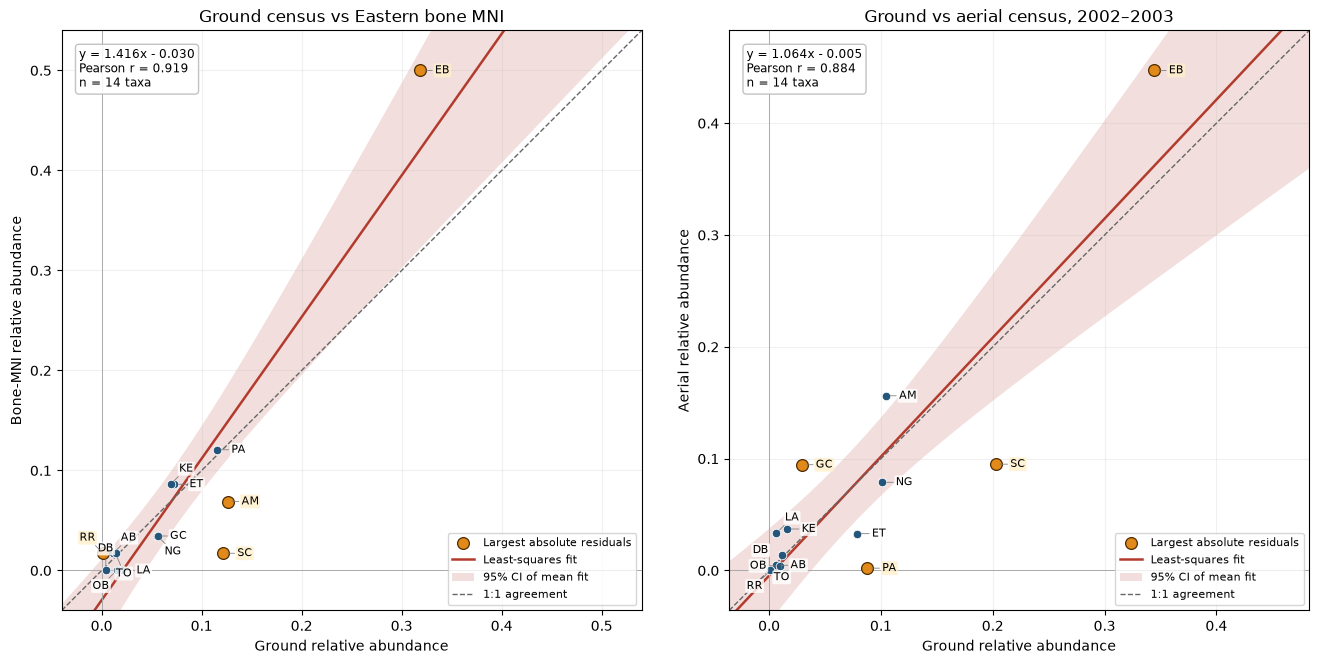

,panel,slope,intercept,pearson,pearson_p,spearman,n_taxa,highlighted_taxa
0,ground vs bone,1.416,-0.030,0.919,0.0,0.732,14,"SC, AM, EB, RR"
1,ground vs aerial,1.064,-0.005,0.884,0.0,0.795,14,"SC, PA, EB, GC"


In [5]:
fig, axes = plt.subplots(1,2,figsize=(13.5,6.5))
stats_ground_bone = labeled_regression_panel(axes[0],ground_all/ground_all.sum(),bone_window/bone_window.sum(),'Ground census vs Eastern bone MNI','Ground relative abundance','Bone-MNI relative abundance',highlight_count=4)
stats_ground_aerial = labeled_regression_panel(axes[1],g_pool/g_pool.sum(),a_pool/a_pool.sum(),'Ground vs aerial census, 2002–2003','Ground relative abundance','Aerial relative abundance',highlight_count=4)
axes[0].legend(loc='lower right',fontsize=8)
axes[1].legend(loc='lower right',fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / 'A3_05_historical_method_comparisons.png',dpi=300,bbox_inches='tight')
fig.savefig(output_dir / 'A3_05_historical_method_comparisons.pdf',bbox_inches='tight')
plt.show()
figure_stats = pd.DataFrame([{'panel':'ground vs bone',**stats_ground_bone},{'panel':'ground vs aerial',**stats_ground_aerial}])
figure_stats.to_csv(output_dir / 'A3_05_figure_statistics.csv', index=False)
figure_stats.round(3)


## Interpretation and copy-ready results

Across 14 taxa shared by the historical ground census and Eastern bones, pooled 1996–2003 ground composition corresponded strongly with Eastern bone MNI assigned to the same estimated-year window (Bray–Curtis = 0.242; Pearson r = 0.919, p < 0.001; Spearman rho = 0.732; ground n = 22,028 counted animals; bone MNI = 58). Using all Eastern primary bone years strengthened the descriptive match (Bray–Curtis = 0.167; r = 0.953; rho = 0.857), indicating that the result is not dependent on the narrow temporal window. Plains zebra contributed 37.4% of the matched-window difference, followed by buffalo (21.4%) and impala (11.9%).

Ground and aerial compositions were not equally similar in both overlapping years. Agreement was moderate in 2002 (Bray–Curtis = 0.421; r = 0.549; rho = 0.461) but strong in 2003 (Bray–Curtis = 0.237; r = 0.870; rho = 0.897). Pooling 2002–2003 gave Bray–Curtis = 0.270, Pearson r = 0.884 (p < 0.001), and Spearman rho = 0.795. These two overlaps show that the methods capture broadly similar dominance but are not interchangeable year by year. No formal method-equivalence test is justified from two paired years.

All seven ground/Earthwatch years were retained as valid primary observations. Excluding the three `Earthwatch ?` years in a source-label sensitivity check changed pooled ground composition only modestly (Bray–Curtis = 0.105; r = 0.980; rho = 0.960), and confirmed-label ground still matched the temporally corresponding bones strongly (Bray–Curtis = 0.236; r = 0.916; rho = 0.714). Plains zebra was the leading ground taxon in every year (mean annual relative abundance 30.9%), followed by warthog (12.6%), impala (12.1%), and buffalo (10.5%). Ground Hill N1 ranged from 6.031 to 8.867.

Exact ground-year and estimated bone-year overlap occurred in 1998, 2002, and 2003, with matched-taxon bone MNI of 25, 23, and 10, respectively. These meet the primary MNI threshold, but weathering-derived years remain approximate; the pooled historical comparison is therefore primary and exact-year matches are an availability audit. Ground evidence is an independent historical living record and is not added to aerial counts.

**Fig. A3.3. Historical method comparisons in Sweetwaters/Eastern OPC.** The left panel compares pooled 1996–2003 ground relative abundance with Eastern bone MNI assigned to estimated years 1996–2003 (14 matched taxa; r = 0.919, p < 0.001). The right panel compares pooled ground and aerial relative abundance in their shared years 2002–2003 (14 taxa; r = 0.884, p < 0.001). Solid red lines are least-squares fits, dashed lines show exact 1:1 agreement, and orange points mark the four largest absolute residuals as descriptive highlights rather than formally tested outliers.

**Taxon codes:** AM — *Aepyceros melampus* (impala); AB — *Alcelaphus buselaphus* (hartebeest); DB — *Diceros bicornis* (black rhinoceros); EB — *Equus burchellii* (plains zebra); ET — *Eudorcas thomsonii* (Thomson's gazelle); GC — *Giraffa camelopardalis* (giraffe); KE — *Kobus ellipsiprymnus* (waterbuck); LA — *Loxodonta africana* (African elephant); NG — *Nanger granti* (Grant's gazelle); OB — *Oryx beisa* (beisa oryx); PA — *Phacochoerus africanus* (warthog); RR — *Redunca redunca* (bohor reedbuck); SC — *Syncerus caffer* (buffalo); TO — *Taurotragus oryx* (common eland).
